In [1]:
import sys
sys.path.append('../../scripts')
import utils as util
import stock_indicators as si
import plot as plot

In [2]:
stockutils = util.StockUtils
preprocesser = util.DataPreprocessor

Load the Data.

In [3]:
data = stockutils.load_stock_data('../../data/Stock Data/MSFT.csv')
data.head(5)

,Ticker,Date,Close,High,Low,Open,Volume
0,MSFT,2009-01-02,14.872976,14.924187,14.170662,14.287715,50084000
1,MSFT,2009-01-05,15.011971,15.121707,14.675444,14.777866,61475200
2,MSFT,2009-01-06,15.187551,15.363130,15.077815,15.180236,58083400
3,MSFT,2009-01-07,14.273087,14.843718,14.251139,14.770560,72709900
4,MSFT,2009-01-08,14.719351,14.770561,14.302350,14.360876,70255400


In [4]:
preprocesser.explore_data(data)

Shape of the data: (3774, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ticker  3774 non-null   object 
 1   Date    3774 non-null   object 
 2   Close   3774 non-null   float64
 3   High    3774 non-null   float64
 4   Low     3774 non-null   float64
 5   Open    3774 non-null   float64
 6   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 206.5+ KB
Info of the data: None


Reorder the columns and keep the ticker symbol.

In [5]:
data = data[['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

In [6]:
stockutils.index_by_date(data)
data.head()

,Ticker,Open,High,Low,Close,Volume
Date,,,,,,
2009-01-02,MSFT,14.287715,14.924187,14.170662,14.872976,50084000
2009-01-05,MSFT,14.777866,15.121707,14.675444,15.011971,61475200
2009-01-06,MSFT,15.180236,15.363130,15.077815,15.187551,58083400
2009-01-07,MSFT,14.770560,14.843718,14.251139,14.273087,72709900
2009-01-08,MSFT,14.360876,14.770561,14.302350,14.719351,70255400


In [7]:
data.describe()

,Open,High,Low,Close,Volume
count,3774.000000,3774.000000,3774.000000,3774.000000,3.774000e+03
mean,102.420838,103.440768,101.374441,102.458692,3.895754e+07
std,100.496751,101.527406,99.431276,100.530006,2.245626e+07
min,11.196224,11.505594,10.953148,11.159394,7.425600e+06
25%,23.721387,23.914675,23.498127,23.723560,2.398462e+07
50%,48.893490,49.195981,48.606149,48.971560,3.279110e+07
75%,166.002089,166.967866,162.911557,165.831585,4.865400e+07
max,378.829959,379.363000,373.301945,377.783630,3.193179e+08


In [8]:
plotter = plot.Plot

#### Analysis Indicators with TA-Lib

In [9]:
technical_indicators = si.IndicatorCalculator

In [10]:
technical_indicators.calculate_technical_indicators(data)
data.tail(5)

,Ticker,Open,High,Low,Close,Volume,SMA_20,SMA_50,EMA_20,EMA_50,RSI_14,MACD,MACDSignal,MACD_hist
Date,,,,,,,,,,,,,,
2023-12-22,MSFT,368.879451,370.360181,367.921911,369.767883,17107500,368.730389,355.078464,368.730389,355.078464,56.363342,2.805416,3.840081,-1.034664
2023-12-26,MSFT,370.182461,372.097540,368.701731,369.846832,12673100,368.535426,356.018111,368.535426,356.018111,56.447998,2.767033,3.625471,-0.858438
2023-12-27,MSFT,368.889342,370.241738,368.020642,369.264465,14905400,368.109468,356.849368,368.109468,356.849368,55.591261,2.658971,3.432171,-0.773200
2023-12-28,MSFT,370.547702,371.623696,369.353256,370.458862,14327000,367.933260,357.715942,367.933260,357.715942,57.031664,2.639285,3.273594,-0.634309
2023-12-29,MSFT,371.169703,372.314805,368.682088,371.209198,18730800,367.791606,358.635943,367.791606,358.635943,57.954296,2.653640,3.149603,-0.495963


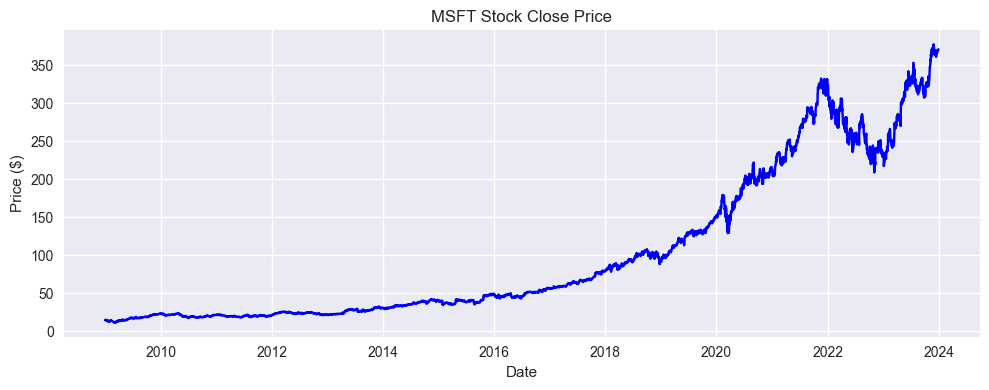

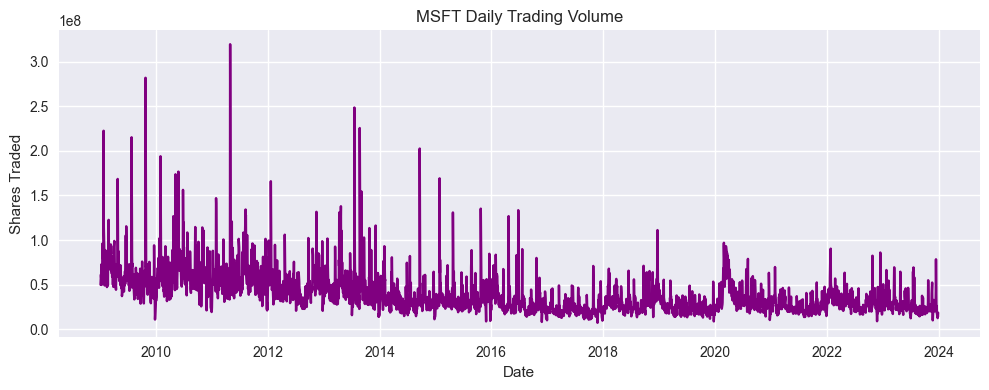

In [11]:
plotter.plot_stock_price(data)

In [12]:
plotter.plot_stock_mva(data)

In [13]:
plotter.plot_ema(data)

In [14]:
plotter.plot_rsi(data)

In [15]:
plotter.plot_macd(data)